In [ ]:
!pip install py-pde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 6.5 MB/s eta 0:00:00


In [ ]:
params = {
    # Equation 1 parameters (N equation)
    'r2': 1.0,      # Growth rate
    'b2': 0.81,     # Carrying capacity
    'c4': 1.0,      # Competition term
    'a3': 0.1,      # Fraction cell kill
    'D_N': 0,    # Diffusion coefficient (assumed)

    # Equation 2 parameters (T equation)
    'r1': 1.1,      # Growth rate
    'b1': 1.0,      # Carrying capacity
    'c2': 0.55,     # Competition term
    'c3': 0.9,      # Competition term
    'a2': 0.3,      # Fraction cell kill
    'D_T': 0.001,    # Diffusion coefficient (assumed)

    # Equation 3 parameters (I equation)
    's': 0.33,      # Immune source rate
    'rho': 0.2,     # Immune response rate
    'alpha': 0.3,   # Immune threshold rate
    'c1': 1.0,      # Competition term
    'd1': 0.2,      # Death rate
    'a1': 0.2,      # Fraction cell kill
    'D_I': 0.001,    # Diffusion coefficient (assumed)

    # Equation 4 parameters (U equation)
    'd2': 1.0,      # Death rate
    'D_U': 0.00,    # Diffusion coefficient (assumed)
    'v_func': lambda t: 0.0  # No treatment initially (modify as needed)
}

r2   = params["r2"]
b2   = params["b2"]
c4   = params["c4"]
a3   = params["a3"]

r1   = params["r1"]
b1   = params["b1"]
c2   = params["c2"]
c3   = params["c3"]
a2   = params["a2"]

s    = params["s"]
rho  = params["rho"]
alpha= params["alpha"]
c1   = params["c1"]
d1   = params["d1"]
a1   = params["a1"]

d2   = params["d2"]

DN   = params["D_N"]
DT   = params["D_T"]
DI   = params["D_I"]
DU   = params["D_U"]

In [ ]:
# ============================================================
# Imports
# ============================================================
import os
import numpy as np
from joblib import Parallel, delayed

from pde import (
    PDE,
    CartesianGrid,
    ScalarField,
    FieldCollection,
    MemoryStorage
)

from scipy.ndimage import gaussian_filter


# ============================================================
# PDE DEFINITION
# ============================================================
params = {
    # Equation 1 parameters (N equation)
    'r2': 1.0,      # Growth rate
    'b2': 0.81,     # Carrying capacity
    'c4': 1.0,      # Competition term
    'a3': 0.1,      # Fraction cell kill
    'D_N': 0,    # Diffusion coefficient (assumed)

    # Equation 2 parameters (T equation)
    'r1': 1.1,      # Growth rate
    'b1': 1.0,      # Carrying capacity
    'c2': 0.55,     # Competition term
    'c3': 0.9,      # Competition term
    'a2': 0.3,      # Fraction cell kill
    'D_T': 0.001,    # Diffusion coefficient (assumed)

    # Equation 3 parameters (I equation)
    's': 0.33,      # Immune source rate
    'rho': 0.2,     # Immune response rate
    'alpha': 0.3,   # Immune threshold rate
    'c1': 1.0,      # Competition term
    'd1': 0.2,      # Death rate
    'a1': 0.2,      # Fraction cell kill
    'D_I': 0.001,    # Diffusion coefficient (assumed)

    # Equation 4 parameters (U equation)
    'd2': 1.0,      # Death rate
    'D_U': 0.00,    # Diffusion coefficient (assumed)
    'v_func': lambda t: 0.0  # No treatment initially (modify as needed)
}
r2   = params["r2"]
b2   = params["b2"]
c4   = params["c4"]
a3   = params["a3"]

r1   = params["r1"]
b1   = params["b1"]
c2   = params["c2"]
c3   = params["c3"]
a2   = params["a2"]

s    = params["s"]
rho  = params["rho"]
alpha= params["alpha"]
c1   = params["c1"]
d1   = params["d1"]
a1   = params["a1"]

d2   = params["d2"]

DN   = params["D_N"]
DT   = params["D_T"]
DI   = params["D_I"]
DU   = params["D_U"]


eq = PDE(
    {
        "N": f"{r2} * N * (1 - {b2} * N) - {c4} * T * N - {a3} * (1 - exp(-U)) * N + {DN} * laplace(N)",
        "T": f"{r1} * T * (1 - {b1} * T) - {c2} * I * T - {c3} * T * N - {a2} * (1 - exp(-U)) * T + {DT} * laplace(T)",
        "I": f"{s} + {rho} * I * T / ({alpha} + T) - {c1} * I * T - {d1} * I - {a1} * (1 - exp(-U)) * I + {DI} * laplace(I)",
        "U": f"- {d2} * U + {DU} * laplace(U)"
    }
)

# ============================================================
# Grid
# ============================================================
grid = CartesianGrid(
    [[-2, 2], [-2, 2], [-2, 2]],
    30
)

GRID_SHAPE = grid.shape  # (30, 30, 30)


# ============================================================
# Realistic Tumor Initial Condition Generator
# ============================================================

def create_spherical_region(grid_shape, center, radius, smoothness=0.5):
    """
    Create a smooth spherical region with soft boundaries.

    Args:
        grid_shape: (nx, ny, nz) tuple
        center: (cx, cy, cz) normalized coordinates [0, 1]
        radius: normalized radius [0, 1]
        smoothness: controls edge sharpness (higher = smoother)

    Returns:
        3D array with values from 0 (outside) to 1 (center)
    """
    nx, ny, nz = grid_shape
    x = np.linspace(0, 1, nx)
    y = np.linspace(0, 1, ny)
    z = np.linspace(0, 1, nz)

    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

    # Distance from center
    dist = np.sqrt((X - center[0])**2 + (Y - center[1])**2 + (Z - center[2])**2)

    # Smooth transition using sigmoid-like function
    region = np.exp(-((dist / radius)**2) / (2 * smoothness**2))

    return region


def create_ellipsoidal_region(grid_shape, center, radii, smoothness=0.5, rotation_angles=(0, 0, 0)):
    """
    Create a smooth ellipsoidal region.

    Args:
        grid_shape: (nx, ny, nz) tuple
        center: (cx, cy, cz) normalized coordinates [0, 1]
        radii: (rx, ry, rz) normalized radii [0, 1]
        smoothness: controls edge sharpness
        rotation_angles: (alpha, beta, gamma) rotation angles in radians

    Returns:
        3D array with values from 0 (outside) to 1 (center)
    """
    nx, ny, nz = grid_shape
    x = np.linspace(0, 1, nx)
    y = np.linspace(0, 1, ny)
    z = np.linspace(0, 1, nz)

    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

    # Translate to center
    X_c = X - center[0]
    Y_c = Y - center[1]
    Z_c = Z - center[2]

    # Ellipsoidal distance
    dist = np.sqrt((X_c / radii[0])**2 + (Y_c / radii[1])**2 + (Z_c / radii[2])**2)

    # Smooth transition
    region = np.exp(-(dist**2) / (2 * smoothness**2))

    return region


def add_noise_to_field(field, rng, noise_level=0.05):
    """Add small spatial variations to make it more realistic."""
    noise = gaussian_filter(rng.normal(size=field.shape), sigma=2.0)
    noise = noise / (np.max(np.abs(noise)) + 1e-12) * noise_level
    return field * (1 + noise)


def generate_realistic_tumor_ic(grid, rng, scenario='single_tumor',
                                 treatment=False, treatment_type='localized'):
    """
    Generate biologically realistic initial conditions for tumor-immune dynamics.

    Scenarios:
        - 'single_tumor': One localized tumor
        - 'multiple_tumors': 2-3 tumor nodules
        - 'invasive': Irregular tumor with infiltration
        - 'early_stage': Small tumor, high normal cells
        - 'advanced': Large tumor, depleted normal cells
        - 'metastatic': Multiple small tumors scattered

    Treatment types:
        - 'none': No drug (U=0)
        - 'localized': Drug concentrated near tumor
        - 'systemic': Drug distributed throughout
        - 'targeted': Drug only in tumor region

    Args:
        grid: CartesianGrid object
        rng: numpy random generator
        scenario: tumor scenario type
        treatment: whether to include drug
        treatment_type: type of treatment if treatment=True
    """

    # Biological parameter ranges
    N_healthy = 1.0 / b2  # Carrying capacity for normal cells (~1.0)
    T_max = 0.8 / b1      # Maximum tumor density (~0.8)
    I_baseline = s / d1    # Baseline immune level (~0.5)

    # Initialize fields
    N_data = np.ones(GRID_SHAPE) * N_healthy
    T_data = np.zeros(GRID_SHAPE)
    I_data = np.ones(GRID_SHAPE) * I_baseline
    U_data = np.zeros(GRID_SHAPE)

    # ==========================================
    # Generate tumor regions based on scenario
    # ==========================================

    if scenario == 'single_tumor':
        # Single spherical tumor
        center = (0.5, 0.5, 0.5)
        radius = rng.uniform(0.15, 0.25)
        tumor_region = create_spherical_region(GRID_SHAPE, center, radius, smoothness=0.3)

        # Tumor density: high in center, lower at edges
        T_data = tumor_region * rng.uniform(0.5, 0.8) * T_max

    elif scenario == 'multiple_tumors':
        # 2-3 separate tumor nodules
        n_tumors = rng.integers(2, 4)
        for _ in range(n_tumors):
            center = (rng.uniform(0.2, 0.8), rng.uniform(0.2, 0.8), rng.uniform(0.2, 0.8))
            radius = rng.uniform(0.1, 0.2)
            tumor_region = create_spherical_region(GRID_SHAPE, center, radius, smoothness=0.3)
            T_data = np.maximum(T_data, tumor_region * rng.uniform(0.4, 0.7) * T_max)

    elif scenario == 'invasive':
        # Irregular tumor with infiltration
        center = (0.5, 0.5, 0.5)
        radii = (rng.uniform(0.15, 0.25), rng.uniform(0.12, 0.22), rng.uniform(0.15, 0.25))
        tumor_region = create_ellipsoidal_region(GRID_SHAPE, center, radii, smoothness=0.5)

        # Add irregular infiltration pattern
        infiltration = gaussian_filter(rng.normal(size=GRID_SHAPE), sigma=2.0)
        infiltration = (infiltration - infiltration.min()) / (infiltration.max() - infiltration.min())
        tumor_region = tumor_region * (0.7 + 0.3 * infiltration)

        T_data = tumor_region * rng.uniform(0.5, 0.8) * T_max

    elif scenario == 'early_stage':
        # Small tumor, mostly healthy tissue
        center = (0.5, 0.5, 0.5)
        radius = rng.uniform(0.08, 0.15)
        tumor_region = create_spherical_region(GRID_SHAPE, center, radius, smoothness=0.2)
        T_data = tumor_region * rng.uniform(0.3, 0.5) * T_max

    elif scenario == 'advanced':
        # Large tumor, significant normal cell depletion
        center = (0.5, 0.5, 0.5)
        radius = rng.uniform(0.25, 0.35)
        tumor_region = create_spherical_region(GRID_SHAPE, center, radius, smoothness=0.4)
        T_data = tumor_region * rng.uniform(0.6, 0.9) * T_max

    elif scenario == 'metastatic':
        # Multiple small tumors scattered
        n_tumors = rng.integers(4, 8)
        for _ in range(n_tumors):
            center = (rng.uniform(0.15, 0.85), rng.uniform(0.15, 0.85), rng.uniform(0.15, 0.85))
            radius = rng.uniform(0.05, 0.12)
            tumor_region = create_spherical_region(GRID_SHAPE, center, radius, smoothness=0.25)
            T_data = np.maximum(T_data, tumor_region * rng.uniform(0.3, 0.6) * T_max)

    else:
        raise ValueError(f"Unknown scenario: {scenario}")

    # ==========================================
    # Normal cells: depleted where tumor is present
    # ==========================================
    tumor_impact = T_data / (T_max + 1e-12)  # Normalized tumor density
    N_data = N_healthy * (1 - 0.8 * tumor_impact)  # Normal cells reduced by 80% max

    # Add small spatial variations
    N_data = add_noise_to_field(N_data, rng, noise_level=0.05)

    # ==========================================
    # Immune cells: elevated near tumor boundaries
    # ==========================================
    # Compute tumor gradient (marks boundaries)
    tumor_gradient = np.gradient(T_data)
    tumor_boundary = np.sqrt(sum(g**2 for g in tumor_gradient))
    tumor_boundary = gaussian_filter(tumor_boundary, sigma=1.0)
    tumor_boundary = tumor_boundary / (tumor_boundary.max() + 1e-12)

    # Immune response: baseline + activation near tumor
    I_activation = 2.0  # Fold increase in immune cells
    I_data = I_baseline * (1 + I_activation * tumor_boundary * (T_data > 0.1 * T_max))

    # Also increase immune cells within tumor
    I_data += I_baseline * 0.5 * tumor_impact

    # Add spatial variations
    I_data = add_noise_to_field(I_data, rng, noise_level=0.08)

    # ==========================================
    # Drug concentration U
    # ==========================================
    if treatment:
        U_max = 0.5  # Maximum drug concentration

        if treatment_type == 'localized':
            # Drug concentrated near tumor (e.g., local injection)
            tumor_mask = (T_data > 0.05 * T_max).astype(float)
            U_region = gaussian_filter(tumor_mask, sigma=3.0)
            U_data = U_region * rng.uniform(0.3, 0.6) * U_max

        elif treatment_type == 'systemic':
            # Drug distributed throughout (e.g., chemotherapy)
            U_data = np.ones(GRID_SHAPE) * rng.uniform(0.2, 0.4) * U_max
            # Add spatial variations due to perfusion
            U_data = add_noise_to_field(U_data, rng, noise_level=0.15)

        elif treatment_type == 'targeted':
            # Drug only in tumor region (e.g., targeted therapy)
            tumor_mask = (T_data > 0.1 * T_max).astype(float)
            U_data = tumor_mask * rng.uniform(0.4, 0.7) * U_max
            U_data = gaussian_filter(U_data, sigma=1.5)

        elif treatment_type == 'none':
            U_data = np.zeros(GRID_SHAPE)

        else:
            raise ValueError(f"Unknown treatment type: {treatment_type}")

    # ==========================================
    # Ensure non-negative and apply bounds
    # ==========================================
    N_data = np.clip(N_data, 0, N_healthy * 1.2)
    T_data = np.clip(T_data, 0, T_max)
    I_data = np.clip(I_data, I_baseline * 0.5, I_baseline * 4.0)
    U_data = np.clip(U_data, 0, None)

    # Create ScalarFields
    N = ScalarField(grid, data=N_data)
    T = ScalarField(grid, data=T_data)
    I = ScalarField(grid, data=I_data)
    U = ScalarField(grid, data=U_data)

    return FieldCollection([N, T, I, U])


# ============================================================
# Generate diverse set of initial conditions
# ============================================================

def generate_diverse_ic_set(grid, n_conditions=50, seed=42):
    """
    Generate a diverse set of initial conditions covering various scenarios.

    Returns:
        List of FieldCollection objects
    """
    rng = np.random.default_rng(seed)

    scenarios = ['single_tumor', 'multiple_tumors', 'invasive',
                 'early_stage', 'advanced', 'metastatic']
    treatment_types = ['none', 'localized', 'systemic', 'targeted']

    ics = []

    for i in range(n_conditions):
        # Randomly select scenario
        scenario = rng.choice(scenarios)

        # Randomly decide on treatment (30% chance)
        treatment = rng.uniform() < 0.3
        treatment_type = rng.choice(treatment_types) if treatment else 'none'

        print(f"Generating IC {i+1}/{n_conditions}: {scenario}, treatment={treatment_type}")

        ic = generate_realistic_tumor_ic(
            grid, rng,
            scenario=scenario,
            treatment=treatment,
            treatment_type=treatment_type
        )

        ics.append(ic)

    return ics


# ============================================================
# Visualization helper
# ============================================================

def visualize_ic_slice(ic, z_slice=15, figsize=(15, 4)):
    """
    Visualize a 2D slice of the initial condition.
    """
    import matplotlib.pyplot as plt

    N, T, I, U = ic

    fig, axes = plt.subplots(1, 4, figsize=figsize)

    # N - Normal cells
    im0 = axes[0].imshow(N.data[:, :, z_slice].T, origin='lower', cmap='Greens')
    axes[0].set_title('Normal Cells (N)')
    plt.colorbar(im0, ax=axes[0])

    # T - Tumor cells
    im1 = axes[1].imshow(T.data[:, :, z_slice].T, origin='lower', cmap='Reds')
    axes[1].set_title('Tumor Cells (T)')
    plt.colorbar(im1, ax=axes[1])

    # I - Immune cells
    im2 = axes[2].imshow(I.data[:, :, z_slice].T, origin='lower', cmap='Blues')
    axes[2].set_title('Immune Cells (I)')
    plt.colorbar(im2, ax=axes[2])

    # U - Drug
    im3 = axes[3].imshow(U.data[:, :, z_slice].T, origin='lower', cmap='Purples')
    axes[3].set_title('Drug (U)')
    plt.colorbar(im3, ax=axes[3])

    plt.tight_layout()
    plt.show()


# ============================================================
# Example usage
# ============================================================


Scenario: single_tumor
Normal cells (N): min=0.6659, max=1.2888, mean=1.2337
Tumor cells (T):  min=0.0000, max=0.4592, mean=0.0023
Immune cells (I): min=1.5180, max=5.4318, mean=1.6692
Drug (U):         min=0.0000, max=0.1109, mean=0.0033


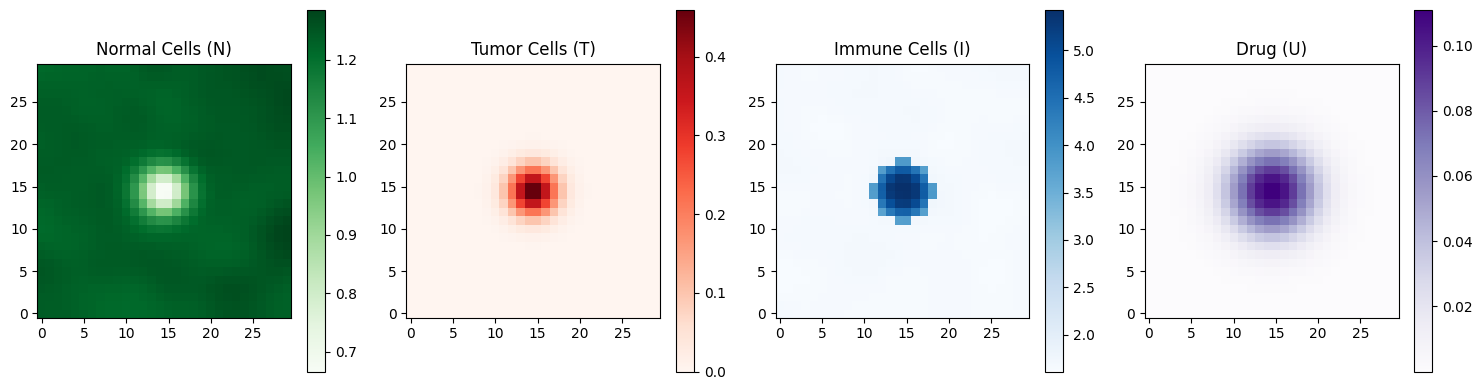


Scenario: multiple_tumors
Normal cells (N): min=0.8085, max=1.2736, mean=1.2328
Tumor cells (T):  min=0.0000, max=0.3470, mean=0.0008
Immune cells (I): min=1.5180, max=5.3543, mean=1.6537
Drug (U):         min=0.0000, max=0.0447, mean=0.0012


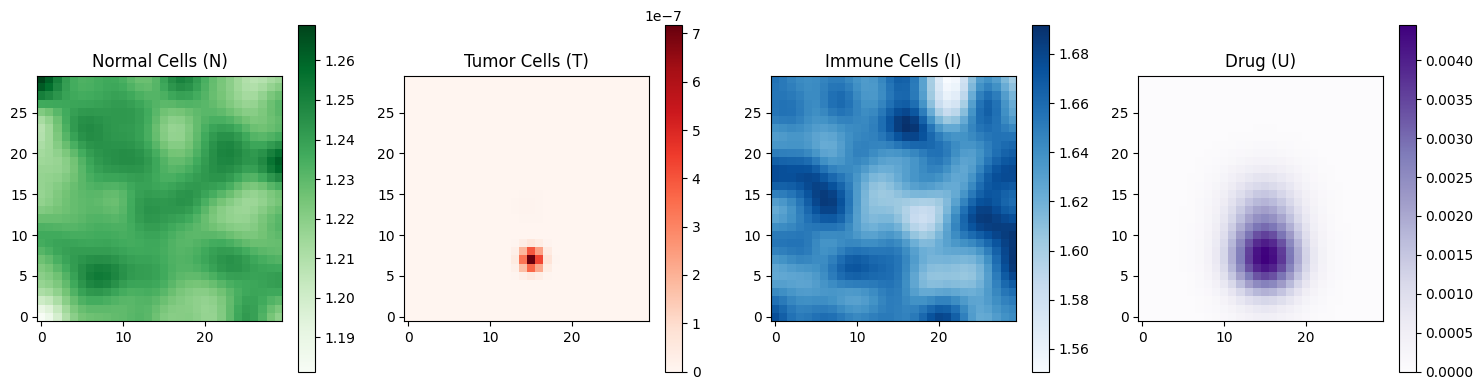


Scenario: invasive
Normal cells (N): min=0.7025, max=1.2963, mean=1.2294
Tumor cells (T):  min=0.0000, max=0.4306, mean=0.0044
Immune cells (I): min=1.5434, max=5.3746, mean=1.6994
Drug (U):         min=0.0000, max=0.1501, mean=0.0066


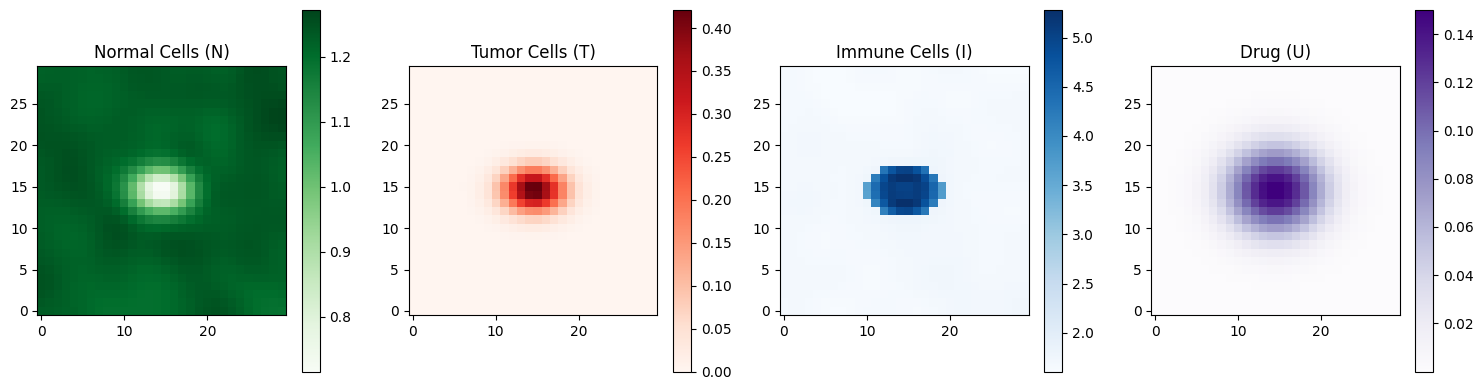


Scenario: early_stage
Normal cells (N): min=1.0167, max=1.2963, mean=1.2345
Tumor cells (T):  min=0.0000, max=0.1753, mean=0.0001
Immune cells (I): min=1.5180, max=5.0923, mean=1.6517
Drug (U):         min=0.0000, max=0.0029, mean=0.0000


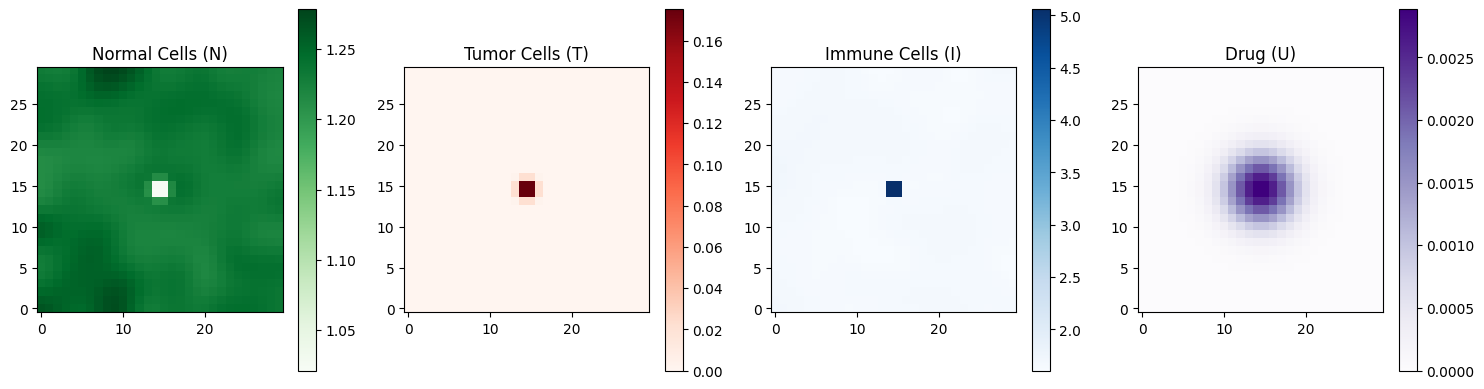


Scenario: advanced
Normal cells (N): min=0.6304, max=1.2936, mean=1.2189
Tumor cells (T):  min=0.0000, max=0.4819, mean=0.0127
Immune cells (I): min=1.5180, max=5.4028, mean=1.7914
Drug (U):         min=0.0000, max=0.1876, mean=0.0153


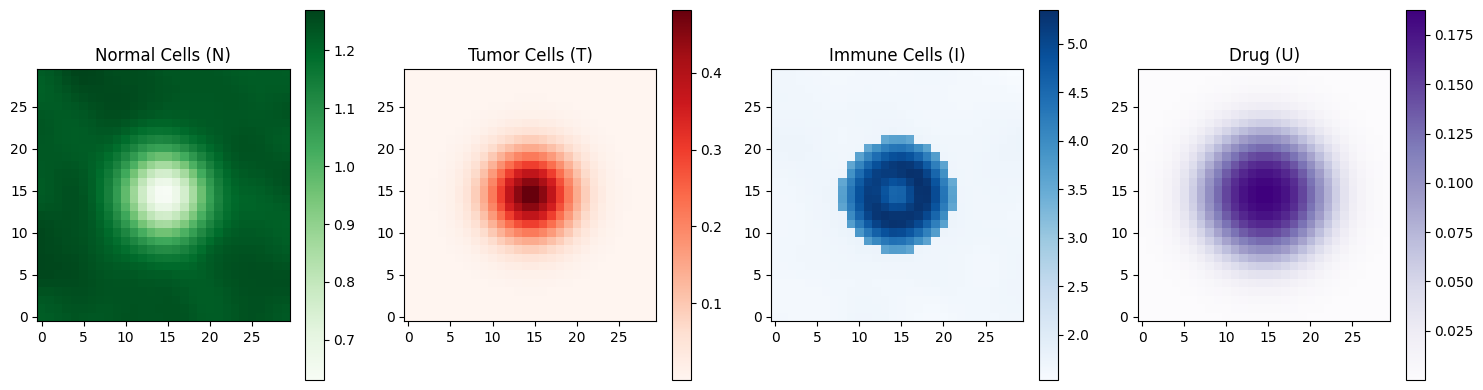


Scenario: metastatic
Normal cells (N): min=0.7800, max=1.2725, mean=1.2333
Tumor cells (T):  min=0.0000, max=0.3581, mean=0.0003
Immune cells (I): min=1.5462, max=5.2647, mean=1.6549
Drug (U):         min=0.0000, max=0.0102, mean=0.0004


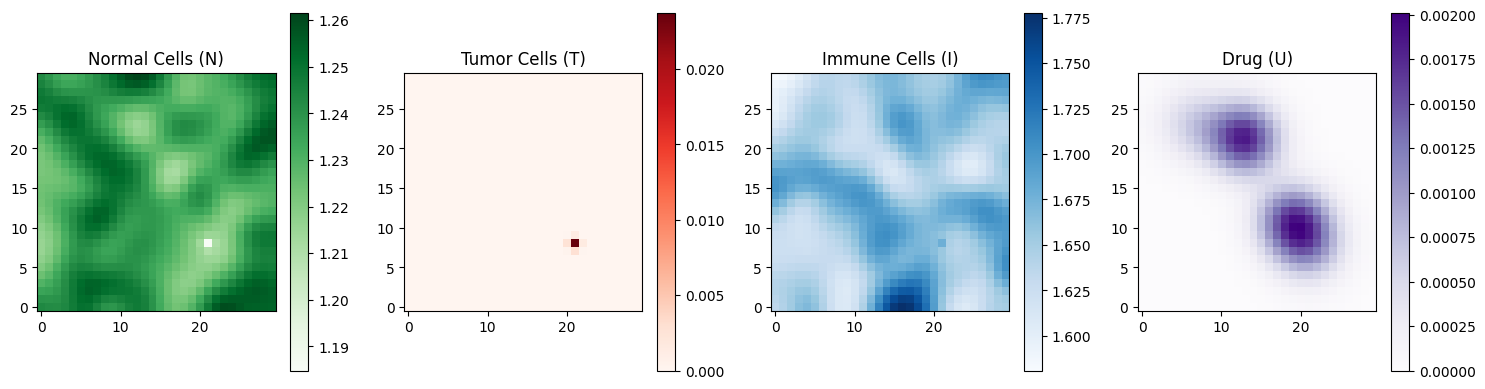


Generating diverse IC set for training...
Generating IC 1/10: single_tumor, treatment=none
Generating IC 2/10: advanced, treatment=none
Generating IC 3/10: single_tumor, treatment=none
Generating IC 4/10: single_tumor, treatment=systemic
Generating IC 5/10: single_tumor, treatment=systemic
Generating IC 6/10: advanced, treatment=systemic
Generating IC 7/10: invasive, treatment=none
Generating IC 8/10: multiple_tumors, treatment=none
Generating IC 9/10: invasive, treatment=none
Generating IC 10/10: invasive, treatment=none


In [ ]:

rng = np.random.default_rng(42)

# Generate single example for each scenario
scenarios = ['single_tumor', 'multiple_tumors', 'invasive',
              'early_stage', 'advanced', 'metastatic']

for scenario in scenarios:
    print(f"\n{'='*60}")
    print(f"Scenario: {scenario}")
    print(f"{'='*60}")

    ic = generate_realistic_tumor_ic(
        grid, rng,
        scenario=scenario,
        treatment=True,
        treatment_type='localized'
    )

    # Print statistics
    N, T, I, U = ic
    print(f"Normal cells (N): min={N.data.min():.4f}, max={N.data.max():.4f}, mean={N.data.mean():.4f}")
    print(f"Tumor cells (T):  min={T.data.min():.4f}, max={T.data.max():.4f}, mean={T.data.mean():.4f}")
    print(f"Immune cells (I): min={I.data.min():.4f}, max={I.data.max():.4f}, mean={I.data.mean():.4f}")
    print(f"Drug (U):         min={U.data.min():.4f}, max={U.data.max():.4f}, mean={U.data.mean():.4f}")

    visualize_ic_slice(ic, z_slice=15)

# Generate diverse set for training
print("\n" + "="*60)
print("Generating diverse IC set for training...")
print("="*60)
ics = generate_diverse_ic_set(grid, n_conditions=10, seed=42)

In [ ]:
def solve_ic_parallel(field_Collection, t_range, dt):
    storage = MemoryStorage()

    eq.solve(
        field_Collection,
        t_range=t_range,
        dt=dt,
        tracker=[storage.tracker()]
    )

    sol = np.asarray(storage.data, dtype=np.float32)
    return sol

In [ ]:
len(ics)

10

In [ ]:
import numpy as np
n_ic = len(ics)
t_range = 14
dt = 1e-3

n_jobs = 2

print(f"Running {n_ic} ICs on {n_jobs} workers")
# ------------------------
# Parallel solve
# ------------------------
results = Parallel(
    n_jobs=n_jobs,
    backend="loky",
    verbose=10
)(
    delayed(solve_ic_parallel)(
        ics[i], t_range, dt
    )
    for i in range(n_ic)
)

# ------------------------
# Aggregate results
# ------------------------


Running 10 ICs on 2 workers


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:  2.7min
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:  5.3min
[Parallel(n_jobs=2)]: Done  10 out of  10 | elapsed: 12.7min finished


ValueError: too many values to unpack (expected 2)

In [ ]:
len(results)

10

In [ ]:
solutions = np.zeros(
    (n_ic, 15, 4, 30, 30, 30),
    dtype=np.float32
)

for i, sol in enumerate(results):
    solutions[i] = sol

print("Final dataset shape:", solutions.shape)

# ------------------------
# Save dataset
# ------------------------
np.save("pde_dataset_3d.npy", solutions)

Final dataset shape: (10, 15, 4, 30, 30, 30)
